In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent

RECRUITING_DIR = (
    ROOT / "data" / "processed" / "player" / "recruiting"
)

YEARS = range(2015, 2026)

frames = []

for year in YEARS:
    path = RECRUITING_DIR / f"recruiting_{year}.csv"

    df = pd.read_csv(path)

    df["source_file"] = path.name

    frames.append(df)

recruiting = pd.concat(
    frames,
    ignore_index=True
)

recruiting.head()

,year,team,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count,source_file
0,2015,Air Force,21,21,0.769710,0.8333,0,0,0,recruiting_2015.csv
1,2015,Akron,14,14,0.769443,0.8061,0,0,0,recruiting_2015.csv
2,2015,Alabama,21,21,0.945852,0.9931,6,14,10,recruiting_2015.csv
3,2015,Alabama State,1,1,0.700000,0.7000,0,0,0,recruiting_2015.csv
4,2015,Albany,2,2,0.700000,0.7000,0,0,0,recruiting_2015.csv


In [2]:
print(f"Rows: {len(recruiting):,}")
print(f"Columns: {recruiting.shape[1]}")
print(f"Seasons: {recruiting['year'].nunique()}")
print(f"Teams: {recruiting['team'].nunique():,}")

Rows: 2,532
Columns: 10
Seasons: 11
Teams: 267


In [4]:
expected_columns = [
    "year",
    "team",
    "recruiting_count",
    "recruiting_rated_count",
    "recruiting_avg_rating",
    "recruiting_max_rating",
    "recruiting_5star_count",
    "recruiting_4star_count",
    "recruiting_top_100_count",
    "source_file",
]

assert recruiting.columns.tolist() == expected_columns

In [5]:
duplicates = recruiting[
    recruiting.duplicated(
        subset=["year", "team"],
        keep=False
    )
]

print(f"Duplicate team-seasons: {len(duplicates)}")

assert len(duplicates) == 0

Duplicate team-seasons: 0


In [6]:
recruiting.isna().sum()

year                        0
team                        0
recruiting_count            0
recruiting_rated_count      0
recruiting_avg_rating       8
recruiting_max_rating       8
recruiting_5star_count      0
recruiting_4star_count      0
recruiting_top_100_count    0
source_file                 0
dtype: int64

In [7]:
rating_missing = recruiting[
    recruiting["recruiting_rated_count"] == 0
]

print(
    "Teams with zero rated recruits:",
    len(rating_missing)
)

print(
    "Rows with missing average rating:",
    recruiting["recruiting_avg_rating"].isna().sum()
)

print(
    "Rows with missing maximum rating:",
    recruiting["recruiting_max_rating"].isna().sum()
)

Teams with zero rated recruits: 8
Rows with missing average rating: 8
Rows with missing maximum rating: 8


In [8]:
assert (
    recruiting.loc[
        recruiting["recruiting_avg_rating"].isna(),
        "recruiting_rated_count"
    ] == 0
).all()

In [9]:
feature_columns = [
    "recruiting_count",
    "recruiting_rated_count",
    "recruiting_avg_rating",
    "recruiting_max_rating",
    "recruiting_5star_count",
    "recruiting_4star_count",
    "recruiting_top_100_count",
]

recruiting[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
recruiting_count,2532.0,14.759874,8.798684,1.0000,7.000000,15.000000,21.000000,82.000000
recruiting_rated_count,2532.0,12.740916,9.131898,0.0000,4.000000,13.000000,20.000000,75.000000
recruiting_avg_rating,2524.0,0.823406,0.042637,0.6996,0.791844,0.820165,0.850313,0.952873
recruiting_max_rating,2524.0,0.864270,0.060800,0.6996,0.824800,0.855600,0.893750,1.000000
recruiting_5star_count,2532.0,0.145340,0.681213,0.0000,0.000000,0.000000,0.000000,9.000000
recruiting_4star_count,2532.0,1.621248,3.845997,0.0000,0.000000,0.000000,1.000000,23.000000
recruiting_top_100_count,2532.0,0.459716,1.607088,0.0000,0.000000,0.000000,0.000000,18.000000


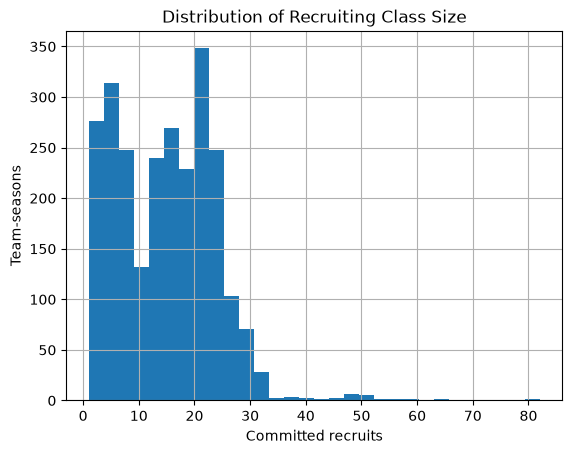

In [10]:
import matplotlib.pyplot as plt

recruiting["recruiting_count"].hist(bins=30)
plt.title("Distribution of Recruiting Class Size")
plt.xlabel("Committed recruits")
plt.ylabel("Team-seasons")
plt.show()

In [11]:
recruiting[feature_columns].corr()

,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count
recruiting_count,1.000000,0.944626,0.429674,0.580806,0.215643,0.383378,0.280436
recruiting_rated_count,0.944626,1.000000,0.482718,0.645446,0.246135,0.442487,0.321518
recruiting_avg_rating,0.429674,0.482718,1.000000,0.907246,0.475015,0.719511,0.566772
recruiting_max_rating,0.580806,0.645446,0.907246,1.000000,0.459746,0.739227,0.562061
recruiting_5star_count,0.215643,0.246135,0.475015,0.459746,1.000000,0.629970,0.887386
recruiting_4star_count,0.383378,0.442487,0.719511,0.739227,0.629970,1.000000,0.796029
recruiting_top_100_count,0.280436,0.321518,0.566772,0.562061,0.887386,0.796029,1.000000


In [12]:
recruiting[
    [
        "recruiting_count",
        "recruiting_rated_count",
        "recruiting_4star_count",
        "recruiting_5star_count",
        "recruiting_top_100_count",
    ]
].corr()

,recruiting_count,recruiting_rated_count,recruiting_4star_count,recruiting_5star_count,recruiting_top_100_count
recruiting_count,1.000000,0.944626,0.383378,0.215643,0.280436
recruiting_rated_count,0.944626,1.000000,0.442487,0.246135,0.321518
recruiting_4star_count,0.383378,0.442487,1.000000,0.629970,0.796029
recruiting_5star_count,0.215643,0.246135,0.629970,1.000000,0.887386
recruiting_top_100_count,0.280436,0.321518,0.796029,0.887386,1.000000


In [13]:
recruiting["rated_share"] = (
    recruiting["recruiting_rated_count"]
    / recruiting["recruiting_count"]
)

recruiting["four_star_share"] = (
    recruiting["recruiting_4star_count"]
    / recruiting["recruiting_count"]
)

recruiting["five_star_share"] = (
    recruiting["recruiting_5star_count"]
    / recruiting["recruiting_count"]
)

In [14]:
teams_to_check = [
    "Georgia",
    "Alabama",
    "Ohio State",
    "Utah",
    "Boise State",
    "Kansas State",
]

recruiting[
    recruiting["team"].isin(teams_to_check)
].sort_values(
    ["team", "year"]
)

,year,team,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count,source_file,rated_share,four_star_share,five_star_share
2,2015,Alabama,21,21,0.945852,0.9931,6,14,10,recruiting_2015.csv,1.000000,0.666667,0.285714
231,2016,Alabama,24,24,0.922829,0.9955,3,14,9,recruiting_2016.csv,1.000000,0.583333,0.125000
470,2017,Alabama,27,27,0.938030,0.9984,6,16,14,recruiting_2017.csv,1.000000,0.592593,0.222222
709,2018,Alabama,21,21,0.914176,0.9987,2,12,4,recruiting_2018.csv,1.000000,0.571429,0.095238
943,2019,Alabama,30,30,0.927477,0.9965,3,23,12,recruiting_2019.csv,1.000000,0.766667,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,2021,Utah,18,17,0.877353,0.9652,0,4,1,recruiting_2021.csv,0.944444,0.222222,0.000000
1815,2022,Utah,18,18,0.867744,0.9587,0,3,1,recruiting_2022.csv,1.000000,0.166667,0.000000
2034,2023,Utah,20,20,0.882365,0.9564,0,7,1,recruiting_2023.csv,1.000000,0.350000,0.000000
2268,2024,Utah,16,16,0.864531,0.9104,0,2,0,recruiting_2024.csv,1.000000,0.125000,0.000000


In [15]:
recruiting.sort_values(
    "recruiting_5star_count",
    ascending=False
).head(20)

,year,team,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count,source_file,rated_share,four_star_share,five_star_share
1839,2023,Alabama,27,27,0.946185,0.9984,9,16,14,recruiting_2023.csv,1.000000,0.592593,0.333333
1794,2022,Texas A&M,30,30,0.950017,0.9997,8,19,18,recruiting_2022.csv,1.000000,0.633333,0.266667
767,2018,Georgia,26,26,0.937673,0.9998,7,14,12,recruiting_2018.csv,1.000000,0.538462,0.269231
1528,2021,Ohio State,26,24,0.944492,1.0000,7,14,14,recruiting_2021.csv,0.923077,0.538462,0.269231
1408,2021,Alabama,26,26,0.952873,0.9989,7,17,16,recruiting_2021.csv,1.000000,0.653846,0.269231
470,2017,Alabama,27,27,0.938030,0.9984,6,16,14,recruiting_2017.csv,1.000000,0.592593,0.222222
2,2015,Alabama,21,21,0.945852,0.9931,6,14,10,recruiting_2015.csv,1.000000,0.666667,0.285714
611,2017,Ohio State,21,21,0.936781,0.9957,5,13,11,recruiting_2017.csv,1.000000,0.619048,0.238095
739,2018,Clemson,17,17,0.934512,0.9999,5,7,7,recruiting_2018.csv,1.000000,0.411765,0.294118
2059,2024,Alabama,28,28,0.931232,0.9982,5,17,9,recruiting_2024.csv,1.000000,0.607143,0.178571


In [16]:
recruiting.sort_values(
    "recruiting_avg_rating",
    ascending=False
).head(20)

,year,team,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count,source_file,rated_share,four_star_share,five_star_share
1408,2021,Alabama,26,26,0.952873,0.9989,7,17,16,recruiting_2021.csv,1.000000,0.653846,0.269231
1794,2022,Texas A&M,30,30,0.950017,0.9997,8,19,18,recruiting_2022.csv,1.000000,0.633333,0.266667
1614,2022,Alabama,26,26,0.948600,0.9911,3,21,15,recruiting_2022.csv,1.000000,0.807692,0.115385
202,2015,USC,20,20,0.947525,0.9985,4,13,12,recruiting_2015.csv,1.000000,0.650000,0.200000
1839,2023,Alabama,27,27,0.946185,0.9984,9,16,14,recruiting_2023.csv,1.000000,0.592593,0.333333
2,2015,Alabama,21,21,0.945852,0.9931,6,14,10,recruiting_2015.csv,1.000000,0.666667,0.285714
1528,2021,Ohio State,26,24,0.944492,1.0000,7,14,14,recruiting_2021.csv,0.923077,0.538462,0.269231
1747,2022,Ohio State,21,21,0.941690,0.9948,2,18,7,recruiting_2022.csv,1.000000,0.857143,0.095238
1898,2023,Georgia,26,26,0.940608,0.9900,5,17,12,recruiting_2023.csv,1.000000,0.653846,0.192308
145,2015,Oregon,8,8,0.939462,0.9909,1,6,2,recruiting_2015.csv,1.000000,0.750000,0.125000


In [17]:
recruiting.sort_values(
    "recruiting_top_100_count",
    ascending=False
).head(20)

,year,team,recruiting_count,recruiting_rated_count,recruiting_avg_rating,recruiting_max_rating,recruiting_5star_count,recruiting_4star_count,recruiting_top_100_count,source_file,rated_share,four_star_share,five_star_share
1794,2022,Texas A&M,30,30,0.950017,0.9997,8,19,18,recruiting_2022.csv,1.000000,0.633333,0.266667
1408,2021,Alabama,26,26,0.952873,0.9989,7,17,16,recruiting_2021.csv,1.000000,0.653846,0.269231
1614,2022,Alabama,26,26,0.948600,0.9911,3,21,15,recruiting_2022.csv,1.000000,0.807692,0.115385
1839,2023,Alabama,27,27,0.946185,0.9984,9,16,14,recruiting_2023.csv,1.000000,0.592593,0.333333
470,2017,Alabama,27,27,0.938030,0.9984,6,16,14,recruiting_2017.csv,1.000000,0.592593,0.222222
1528,2021,Ohio State,26,24,0.944492,1.0000,7,14,14,recruiting_2021.csv,0.923077,0.538462,0.269231
847,2018,Ohio State,27,27,0.931248,0.9963,3,19,13,recruiting_2018.csv,1.000000,0.703704,0.111111
767,2018,Georgia,26,26,0.937673,0.9998,7,14,12,recruiting_2018.csv,1.000000,0.538462,0.269231
943,2019,Alabama,30,30,0.927477,0.9965,3,23,12,recruiting_2019.csv,1.000000,0.766667,0.100000
202,2015,USC,20,20,0.947525,0.9985,4,13,12,recruiting_2015.csv,1.000000,0.650000,0.200000


In [18]:
for year in YEARS:

    final_path = (
        ROOT
        / "data"
        / "processed"
        / "features"
        / "final"
        / f"final_features_{year}.csv"
    )

    final_df = pd.read_csv(final_path)

    modeling_teams = set(
        final_df["homeTeam"].dropna()
    ) | set(
        final_df["awayTeam"].dropna()
    )

    recruiting_teams = set(
        recruiting.loc[
            recruiting["year"] == year,
            "team"
        ]
    )

    matched = modeling_teams & recruiting_teams
    unmatched = modeling_teams - recruiting_teams

    print(
        year,
        "modeling teams:", len(modeling_teams),
        "recruiting teams:", len(recruiting_teams),
        "matched:", len(matched),
        "unmatched:", len(unmatched)
    )

2015 modeling teams: 208 recruiting teams: 228 matched: 193 unmatched: 15
2016 modeling teams: 216 recruiting teams: 239 matched: 210 unmatched: 6
2017 modeling teams: 212 recruiting teams: 239 matched: 203 unmatched: 9
2018 modeling teams: 219 recruiting teams: 234 matched: 208 unmatched: 11
2019 modeling teams: 217 recruiting teams: 230 matched: 205 unmatched: 12
2020 modeling teams: 141 recruiting teams: 236 matched: 139 unmatched: 2
2021 modeling teams: 227 recruiting teams: 205 matched: 192 unmatched: 35
2022 modeling teams: 228 recruiting teams: 225 matched: 203 unmatched: 25
2023 modeling teams: 229 recruiting teams: 220 matched: 195 unmatched: 34
2024 modeling teams: 230 recruiting teams: 237 matched: 211 unmatched: 19
2025 modeling teams: 230 recruiting teams: 239 matched: 206 unmatched: 24


In [19]:
assert (
    recruiting["year"]
    .between(2015, 2025)
).all()

In [20]:
recruiting.groupby("year").agg(
    teams=("team", "nunique"),
    recruits=("recruiting_count", "sum"),
    rated=("recruiting_rated_count", "sum"),
)

,teams,recruits,rated
year,,,
2015,228,2343,2343
2016,239,3691,3235
2017,239,3807,3378
2018,234,3556,3101
2019,230,3590,3220
2020,236,3588,3121
2021,205,3169,2533
2022,225,3081,2495
2023,220,3391,2693
